# Hafta 5 · Ders 10 — Kuvvet Yöntemi ve QR İterasyonu

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Geçen derste `np.linalg.eig`'i *çağırdık*. Ama 4. dereceden öteye polinom kökleri için formül yokken,
bir bilgisayar özdeğerleri nasıl bulur? İteratif olarak.

Bu defter, iki temel özdeğer algoritmasını elle inşa eder:

- **Kuvvet yöntemi** — tekrarlı çarpma, baskın özvektöre yakınsar. Basit ve tam olarak Google'ın
  orijinal PageRank'inin kullandığı şey.
- **QR iterasyonu** — tekrar tekrar çarpanla ve yeniden çarp ($A = QR \to RQ$) ve matris üçgensele
  doğru yürür, *tüm* özdeğerleri köşegende açığa çıkarır. Bu, aslında LAPACK'in yaptığı şeydir.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Kuvvet yöntemi

Herhangi bir başlangıç vektörü seçin ve her adımda yeniden normalleştirerek $A$ ile çarpmaya devam edin.
Bu neden baskın özvektörü bulur? Başlangıç vektörünü özbazda yazın: her bileşen, her iterasyonda kendi
$\lambda_i$'siyle çarpılır. En büyük $|\lambda|$ en hızlı büyür ve sonunda baskın olur, bu yüzden
iterasyon o özvektörle hizalanır.

$$ \mathbf{x}_{k+1} = \frac{A\mathbf{x}_k}{\lVert A\mathbf{x}_k\rVert} \;\longrightarrow\; \text{en büyük }|\lambda|\text{'nın özvektörü} $$

In [2]:
def power_method(A, iters=100, tol=1e-12, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=A.shape[0])
    x /= np.linalg.norm(x)
    history = []
    lam_old = 0.0
    for _ in range(iters):
        y = A @ x
        x = y / np.linalg.norm(y)
        lam = x @ A @ x                 # Rayleigh bölümü = güncel özdeğer tahmini
        history.append(lam)
        if abs(lam - lam_old) < tol:
            break
        lam_old = lam
    return lam, x, history

A = np.array([[2.0, 1.0],
              [1.0, 3.0]])
lam, vec, hist = power_method(A)
ref_vals, ref_vecs = np.linalg.eig(A)
dom = ref_vals[np.argmax(np.abs(ref_vals))]
print(f"kuvvet yöntemi λ  = {lam:.6f}")
print(f"gerçek baskın λ = {dom:.6f}")
check("baskın özdeğer", lam, dom, atol=1e-5)

power method λ  = 3.618034
true dominant λ = 3.618034
[PASS] dominant eigenvalue              max|Δ| = 2.89e-14


True

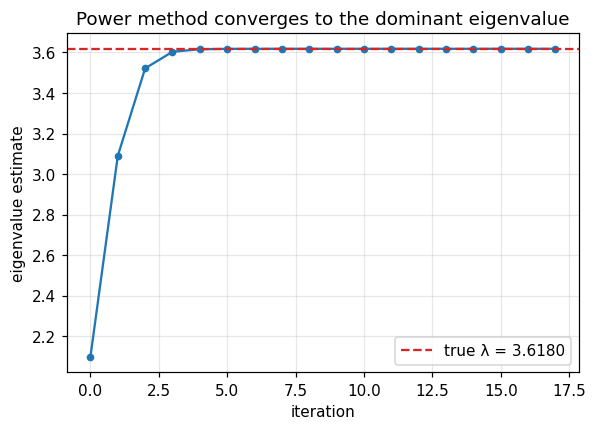

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(hist, "o-", color="C0", ms=4)
plt.axhline(dom, color="C3", ls="--", label=f"gerçek λ = {dom:.4f}")
plt.xlabel("iterasyon"); plt.ylabel("özdeğer tahmini")
plt.title("Kuvvet yöntemi baskın özdeğere yakınsar")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## 2. Yakınsama hızı = spektral boşluk

Kuvvet yöntemi, en büyük iki özdeğerin oranı $|\lambda_2 / \lambda_1|$ tarafından belirlenen bir hızla
yakınsar. Büyük bir boşluk hızlı yakınsama demektir; benzer boyutta özdeğerler acı verici derecede
yavaş ilerleme demektir. Hadi onu farklı boşluklara sahip iki matriste ölçelim.

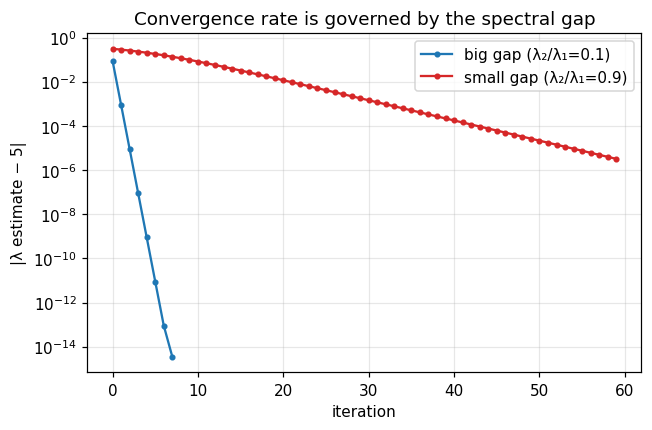

In [4]:
def make_with_eigs(l1, l2, seed=0):
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.normal(size=(2, 2)))
    return Q @ np.diag([l1, l2]) @ Q.T

big_gap   = make_with_eigs(5.0, 0.5)     # oran 0.1  → hızlı
small_gap = make_with_eigs(5.0, 4.5)     # oran 0.9  → yavaş

plt.figure(figsize=(6.5, 4))
for M, name, col in [(big_gap, "büyük boşluk (λ₂/λ₁=0.1)", "C0"),
                     (small_gap, "küçük boşluk (λ₂/λ₁=0.9)", "C3")]:
    _, _, h = power_method(M, iters=60)
    err = np.abs(np.array(h) - 5.0)
    plt.semilogy(err, "o-", ms=3, color=col, label=name)
plt.xlabel("iterasyon"); plt.ylabel("|λ tahmini − 5|")
plt.title("Yakınsama hızı spektral boşluk tarafından yönetilir")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.show()

## 3. Deflasyon: bir sonraki özdeğeri elde etmek

Kuvvet yöntemi yalnızca *baskın* özdeğeri bulur. Bir sonrakini elde etmek için **deflasyon yapın**:
bulunan özçiftin katkısını simetrik bir matristen çıkarın, yeni baskın özdeğeri orijinalin ikincisi
olan, daha küçük spektrumlu bir matris bırakın. Tüm spektrumu soymak için tekrarlayın.

In [5]:
def deflate_symmetric(A, n_eigs=None):
    A = np.asarray(A, float).copy()
    n = A.shape[0]
    n_eigs = n_eigs or n
    eigs = []
    for _ in range(n_eigs):
        lam, v, _ = power_method(A, iters=500)
        eigs.append(lam)
        A = A - lam * np.outer(v, v)        # bu özçifti kaldır (v birim, A simetrik)
    return np.array(eigs)

rng = np.random.default_rng(1)
M = rng.normal(size=(4, 4)); M = M + M.T           # simetrik
mine = np.sort(deflate_symmetric(M))[::-1]
ref = np.sort(np.linalg.eigvalsh(M))[::-1]
print("deflasyon özdeğerleri:", mine)
print("gerçek özdeğerler     :", ref)
check("deflasyon spektrumu", mine, ref, atol=1e-4)

deflation eigenvalues: [ 3.3985  1.4328  0.1975 -2.1903]
true eigenvalues     : [ 3.3985  1.4328  0.1975 -2.1903]
[PASS] deflated spectrum                max|Δ| = 6.93e-13


True

## 4. QR iterasyonu: tüm özdeğerler bir kerede

Şık alternatif deflasyona gerek duymaz. $A = QR$'yi çarpanla, ardından $A' = RQ$ oluşturmak için
**takas et ve yeniden çarp**. Dikkat çekici biçimde $A'$, $A$ ile *aynı özdeğerlere* sahiptir (benzer
matrislerdir) ve tekrarlamak $A$'yı üst-üçgensel forma sürükler — bu noktada özdeğerler köşegende
oturur. Bu, her üretim özçözücüsünün kalbidir.

QR-iteration eigenvalues: [ 3.8936  2.2065  1.1665 -2.8435]
true eigenvalues        : [ 3.8936  2.2065  1.1665 -2.8435]
[PASS] QR iteration spectrum            max|Δ| = 9.33e-15


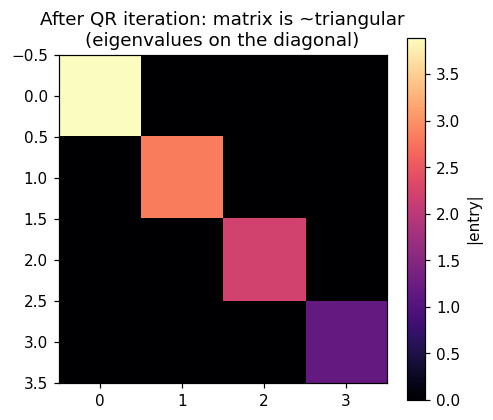

In [6]:
def qr_iteration(A, iters=200):
    A = np.asarray(A, float).copy()
    for _ in range(iters):
        Q, R = np.linalg.qr(A)
        A = R @ Q                      # benzerlik dönüşümü: A ← Q⁻¹ A Q
    return np.diag(A), A               # köşegen özdeğerleri tutar

rng = np.random.default_rng(2)
M = rng.normal(size=(4, 4)); M = M + M.T          # simetrik → reel özdeğerler
diag, final = qr_iteration(M)
print("QR-iterasyonu özdeğerleri:", np.sort(diag)[::-1])
print("gerçek özdeğerler        :", np.sort(np.linalg.eigvalsh(M))[::-1])
check("QR iterasyonu spektrumu", np.sort(diag), np.sort(np.linalg.eigvalsh(M)), atol=1e-6)

plt.figure(figsize=(4.6, 4))
plt.imshow(np.abs(final), cmap="magma")
plt.title("QR iterasyonundan sonra: matris ~üçgensel\n(özdeğerler köşegende)")
plt.colorbar(label="|girdi|"); plt.tight_layout(); plt.show()

## 5. Uygulama: Baskın-özvektör problemi olarak PageRank

Google'ın orijinal sıralaması saf kuvvet yöntemidir. Web'i, gezginlerin bağlantıları rastgele izlediği
bir geçiş matrisi olarak modelleyin; **durağan dağılım** — sıralama — o matrisin baskın özvektörüdür
(özdeğer 1). Küçük bir web inşa edip onu sıfırdan sıralıyoruz.

PageRank scores: [0.1459 0.092  0.2727 0.2484 0.2411]
ranking (best→worst): ['page 2', 'page 3', 'page 4', 'page 0', 'page 1']


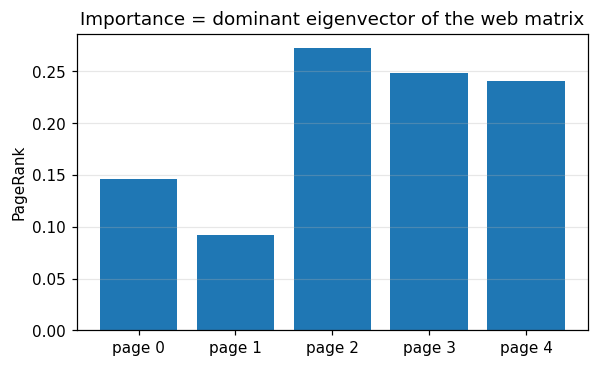

In [7]:
# küçük 5-sayfalık web: links[i][j] = 1, sayfa i'nin sayfa j'ye bağlandığı anlamına gelir
links = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 1, 1, 0],
], float)

# sönümlü sütun-stokastik geçiş matrisi ("rastgele gezgin")
n = len(links)
out_deg = links.sum(axis=1, keepdims=True)
M = (links / out_deg).T
d = 0.85
G = d * M + (1 - d) / n * np.ones((n, n))

rank, vec, _ = power_method(G, iters=200)
scores = np.abs(vec) / np.abs(vec).sum()
order = np.argsort(scores)[::-1]
print("PageRank skorları:", np.round(scores, 4))
print("sıralama (en iyi→en kötü):", [f"sayfa {i}" for i in order])

plt.figure(figsize=(6, 3.5))
plt.bar(range(n), scores, color="C0")
plt.xticks(range(n), [f"sayfa {i}" for i in range(n)])
plt.ylabel("PageRank"); plt.title("Önem = web matrisinin baskın özvektörü")
plt.grid(True, axis="y", alpha=0.3); plt.show()

## Alıştırmalar

1. **Rayleigh bölümü.** $\lambda$'yı, birim $\mathbf{x}$ için $\mathbf{x}^\top A\mathbf{x}$ olarak tahmin ettik. $\mathbf{x}$ bir özvektör olduğunda tam özdeğeri verdiğini doğrulayın.
2. **Kaydırılmış kuvvet yöntemi.** Kuvvet yöntemini $(A - \mu I)^{-1}$'e uygulamanın, $\mu$'ya *en yakın* özdeğeri bulduğunu gösterin (ters iterasyon). Seçilen bir $\mu$ için uygulayın.
3. **Markov kararlı durumu.** Bir sütun-stokastik matris oluşturun ve baskın özdeğerinin tam olarak 1 olduğunu, özvektörün uzun-vadeli dağılımı verdiğini doğrulayın.

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. Rayleigh bölümü bir özvektör üzerinde tamdır
A = np.array([[2.0, 1.0], [1.0, 3.0]])
w, V = np.linalg.eig(A)
v = V[:, 0]
print("Rayleigh(v) =", round(v @ A @ v / (v @ v), 6), " vs λ =", round(w[0], 6))

# 3. Markov kararlı durumu: baskın özdeğer = 1
P = np.array([[0.7, 0.2], [0.3, 0.8]])     # sütunlar 1'e toplanır
lam, vec, _ = power_method(P, iters=300)
steady = np.abs(vec) / np.abs(vec).sum()
print("baskın özdeğer:", round(lam, 6), " (1.0 olmalı)")
print("kararlı-durum dağılımı:", np.round(steady, 4))

Rayleigh(v) = 1.381966  vs λ = 1.381966
dominant eigenvalue: 1.0  (should be 1.0)
steady-state distribution: [0.4 0.6]


## Özet ve sırada ne var

Kuvvet yöntemi, tekrarlı çarpma ile baskın özvektörü çıkarır; deflasyon geri kalanını soyar; QR
iterasyonu tüm spektrumu bir kerede açığa çıkarır. PageRank, bunların oyuncak olmadığını gösterdi —
web'i sıralarlar.

**Sırada — `11_tekil_deger_ayrisimi.ipynb`:** *her şeyi* — özdeğerler, ortogonallik, izdüşüm —
makine öğrenmesindeki en önemli çarpanlama olan **SVD**'de birleştiriyor ve onu $A^\top A$'nın
özayrışımından inşa ediyoruz.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 5 · Ders 10*